# Extension Deep Learning — CNN from scratch vs pretrained

Ce notebook entraîne et évalue deux approches Deep Learning pour la détection de maladies des plantes, puis compare les résultats avec le pipeline classique (ML) basé sur l'extraction de caractéristiques.

**Approches évaluées :**
1. **SimpleCNN** — réseau convolutif entraîné from scratch *(ignoré dans cette version)*
2. **ResNet18** — fine-tuning d'un modèle pré-entraîné sur ImageNet

Le résultat final est une comparaison d'accuracy entre le meilleur modèle DL et le meilleur modèle ML classique (Random Forest sur les caractéristiques extraites).


## Prérequis

Installez les dépendances si nécessaire :

```bash
pip install torch torchvision timm scikit-learn matplotlib seaborn
```

Un GPU (CUDA) est recommandé mais non obligatoire. Le notebook détecte automatiquement le device disponible.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
# Enable cuDNN auto-tuner for fixed-size inputs to improve performance
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True
print('cudnn.benchmark:', torch.backends.cudnn.benchmark)
# DataLoader/transfer settings
pin_memory = True if torch.cuda.is_available() else False
use_amp = True if torch.cuda.is_available() else False


Device: cuda
cudnn.benchmark: True


In [2]:
# Jeu de données et transformations (ajuster dataset_root si nécessaire)
dataset_root = '../data/raw/PlantVillage/tomato'
img_size = 224
#image_limit_per_class=500
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Construction de la liste d'images depuis les dossiers bruts (même logique que le pipeline ML)
from PIL import Image
from sklearn.model_selection import train_test_split

class ImageListDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, labels, class_to_idx, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path).convert('RGB')
        label = self.class_to_idx[self.labels[idx]]
        if self.transform is not None:
            img = self.transform(img)
        return img, label

class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = list(indices)
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        if self.transform is not None:
            image = self.transform(image)
        return image, label

image_paths = []
labels_list = []
for class_name in os.listdir(dataset_root):
    class_path = os.path.join(dataset_root, class_name)
    if not os.path.isdir(class_path):
        continue
    files = [
        os.path.join(class_path, f)
        for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.png', '.jpeg'))
    ]
    # appliquer la limite optionnelle par classe si la variable existe
    try:
        limit = image_limit_per_class
    except NameError:
        limit = None
    if limit:
        files = files[:limit]
    for f in files:
        image_paths.append(f)
        labels_list.append(class_name)

if len(image_paths) == 0:
    raise FileNotFoundError(f'No images found under {dataset_root}')

class_names = sorted(list(set(labels_list)))
class_to_idx = {c:i for i,c in enumerate(class_names)}
base_dataset = ImageListDataset(image_paths, labels_list, class_to_idx, transform=None)
num_samples = len(base_dataset)
num_classes = len(class_names)
indices = np.arange(num_samples)
train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=labels_list, random_state=42)
train_dataset = SubsetWithTransform(base_dataset, train_idx, train_transform)
val_dataset = SubsetWithTransform(base_dataset, val_idx, val_transform)

batch_size = 64
num_workers = 0
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=num_workers,
                          pin_memory=pin_memory, persistent_workers=(num_workers > 0))
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=num_workers,
                          pin_memory=pin_memory, persistent_workers=(num_workers > 0))
dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}


In [3]:
### SimpleCNN (from-scratch) — ignoré

# Le réseau SimpleCNN from-scratch est intentionnellement ignoré dans ce notebook.
# Nous utilisons uniquement ResNet18 pré-entraîné (transfer learning) pour une convergence plus rapide et une meilleure accuracy.

# Pour activer l'entraînement from-scratch ultérieurement, définir et exécuter une cellule dédiée.


In [4]:
# Fonctions d'entraînement / évaluation (avec AMP optionnel et transferts non-bloquants)
from torch import amp

def train_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        if scaler is not None:
            with amp.autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        preds = torch.argmax(outputs, dim=1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data).item()
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_corrects / len(loader.dataset)
    return epoch_loss, epoch_acc

def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with amp.autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    print('Accuracy:', acc)
    print(classification_report(all_labels, all_preds, target_names=class_names))
    return acc, all_labels, all_preds

def fit(model, dataloaders, criterion, optimizer, device, epochs=5, use_amp=True):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    scaler = amp.GradScaler('cuda') if (use_amp and torch.cuda.is_available()) else None
    for epoch in range(epochs):
        # --- entraînement ---
        loss, acc = train_epoch(model, dataloaders['train'], criterion, optimizer, device, scaler=scaler)
        history['train_loss'].append(loss)
        history['train_acc'].append(acc)

        # --- validation ---
        model.eval()
        val_loss_sum, val_correct = 0.0, 0
        with torch.no_grad():
            for inputs, labels in dataloaders['val']:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                with amp.autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                    outputs = model(inputs)
                    v_loss  = criterion(outputs, labels)
                preds = torch.argmax(outputs, dim=1)
                val_loss_sum += v_loss.item() * inputs.size(0)
                val_correct  += torch.sum(preds == labels.data).item()

        val_loss_epoch = val_loss_sum / len(dataloaders['val'].dataset)
        val_acc_epoch  = val_correct  / len(dataloaders['val'].dataset)
        history['val_loss'].append(val_loss_epoch)
        history['val_acc'].append(val_acc_epoch)

        print(f'Epoch {epoch+1}/{epochs} - loss: {loss:.4f} - acc: {acc:.4f}'
              f' - val_loss: {val_loss_epoch:.4f} - val_acc: {val_acc_epoch:.4f}')
    return history



In [5]:
# Entraînement SimpleCNN ignoré — utilisation de ResNet18 pré-entraîné uniquement
enable_scratch = False
print('Entraînement SimpleCNN ignoré. Utilisation de ResNet18 (transfer learning) uniquement.')


Entraînement SimpleCNN ignoré. Utilisation de ResNet18 (transfer learning) uniquement.


In [6]:
# Fine-tuning ResNet18 pré-entraîné
try:
    from torchvision.models import resnet18, ResNet18_Weights
    weights = ResNet18_Weights.DEFAULT
    model_pre = resnet18(weights=weights)
except Exception:
    model_pre = models.resnet18(pretrained=True)

num_ftrs = model_pre.fc.in_features
model_pre.fc = nn.Linear(num_ftrs, num_classes)
model_pre = model_pre.to(device)

# Vérification GPU : confirmer que le batch et le modèle sont sur le GPU
try:
    batch = next(iter(dataloaders['train']))
except Exception:
    try:
        batch = next(iter(train_loader))
    except Exception:
        batch = None
if batch is not None:
    try:
        sample_inputs, sample_labels = batch
    except Exception:
        sample_inputs = batch[0]
        sample_labels = batch[1] if len(batch) > 1 else None
    print('Original batch device:', getattr(sample_inputs, 'device', 'cpu'))
    sample_inputs = sample_inputs.to(device, non_blocking=True)
    if sample_labels is not None:
        sample_labels = sample_labels.to(device, non_blocking=True)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    print('After .to(device): batch device:', getattr(sample_inputs, 'device', None))
else:
    print('No batch available to test on train_loader')
print('Model device:', next(model_pre.parameters()).device)
if torch.cuda.is_available():
    print('GPU memory used (MB):', torch.cuda.memory_allocated(0)/1e6)
else:
    print('CUDA not available')

for name, param in model_pre.named_parameters():
    if "layer4" not in name and "fc" not in name:
        param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_pre.parameters()), lr=3e-4)
epochs = 10
history_pre = fit(model_pre, dataloaders, criterion, optimizer, device, epochs=epochs)
acc_pre, y_true_pre, y_pred_pre = evaluate(model_pre, dataloaders['val'], device)
torch.save(model_pre.state_dict(), '../results/combined_run/models/model_resnet18.pth')
print('Modèle model_resnet18 sauvegardé')


Original batch device: cpu
After .to(device): batch device: cuda:0
Model device: cuda:0
GPU memory used (MB): 83.316736
Epoch 1/10 - loss: 0.3659 - acc: 0.8797 - val_loss: 0.1125 - val_acc: 0.9647
Epoch 2/10 - loss: 0.1632 - acc: 0.9451 - val_loss: 0.1276 - val_acc: 0.9519
Epoch 3/10 - loss: 0.1284 - acc: 0.9564 - val_loss: 0.0903 - val_acc: 0.9682
Epoch 4/10 - loss: 0.0969 - acc: 0.9665 - val_loss: 0.0651 - val_acc: 0.9781
Epoch 5/10 - loss: 0.0875 - acc: 0.9692 - val_loss: 0.0655 - val_acc: 0.9750
Epoch 6/10 - loss: 0.0739 - acc: 0.9739 - val_loss: 0.0510 - val_acc: 0.9822
Epoch 7/10 - loss: 0.0719 - acc: 0.9756 - val_loss: 0.0524 - val_acc: 0.9819
Epoch 8/10 - loss: 0.0751 - acc: 0.9745 - val_loss: 0.0627 - val_acc: 0.9791
Epoch 9/10 - loss: 0.0789 - acc: 0.9738 - val_loss: 0.0492 - val_acc: 0.9822
Epoch 10/10 - loss: 0.0593 - acc: 0.9807 - val_loss: 0.0484 - val_acc: 0.9819
Accuracy: 0.9818919762722448
                                             precision    recall  f1-score   sup

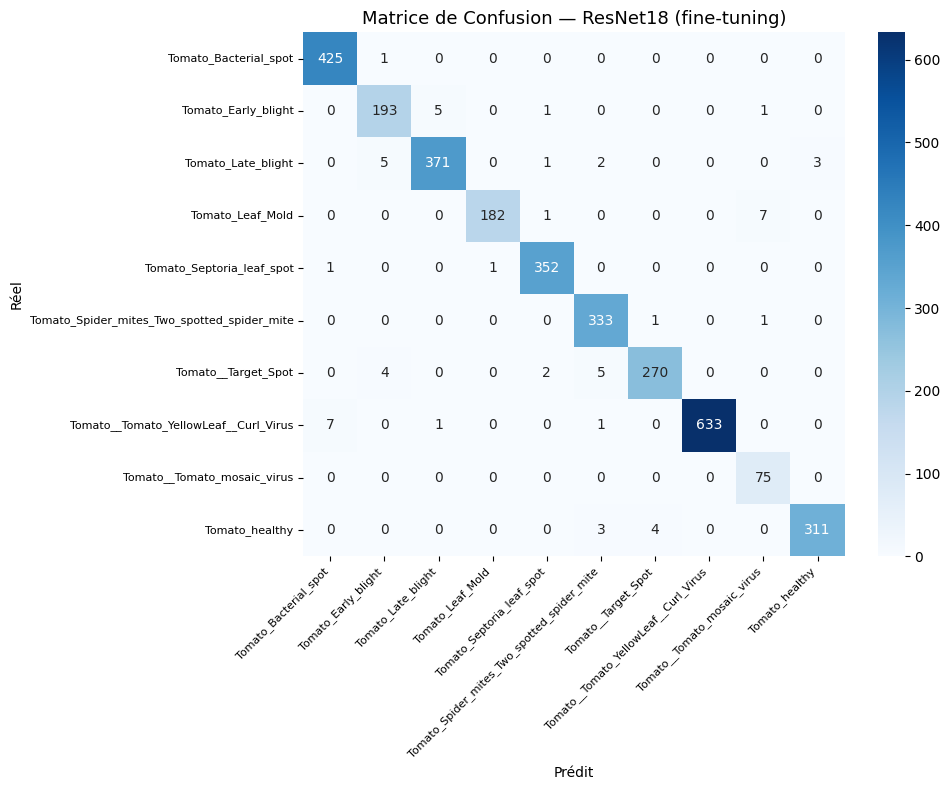

Matrice de confusion sauvegardée dans results/plots/part5_deep_learning/


In [7]:
# ============================================================
# Matrice de Confusion — ResNet18 (heatmap)
# ============================================================

import os
from sklearn.metrics import confusion_matrix

os.makedirs('../results/plots/part5_deep_learning', exist_ok=True)

cm = confusion_matrix(y_true_pre, y_pred_pre)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Matrice de Confusion — ResNet18 (fine-tuning)', fontsize=13)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('../results/plots/part5_deep_learning/confusion_resnet18.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Matrice de confusion sauvegardée dans results/plots/part5_deep_learning/")


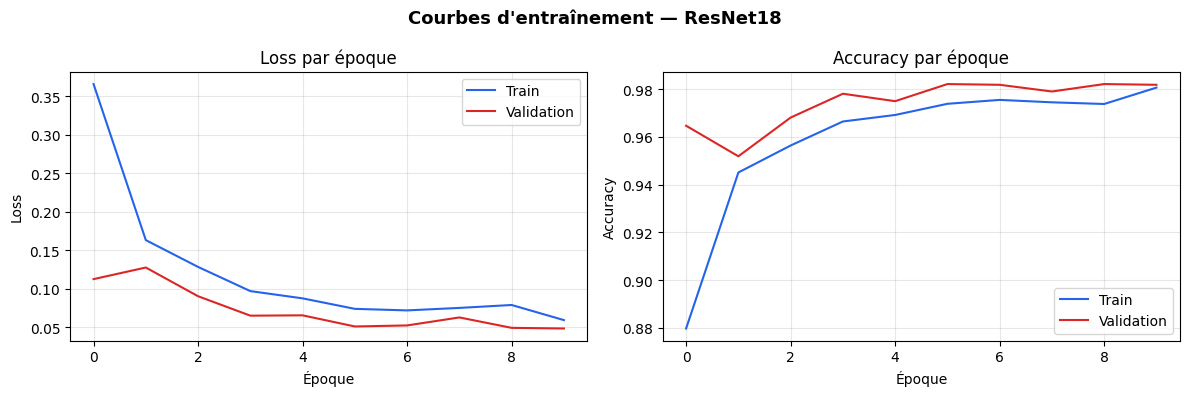

In [8]:
# ============================================================
# Courbes d'entraînement — ResNet18
# ============================================================

if 'history_pre' in dir() and history_pre is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))


if 'val_loss' in history_pre and history_pre['val_loss']:
    ax1.plot(history_pre['train_loss'], label='Train', color='#2563eb')
    ax1.plot(history_pre['val_loss'], label='Validation', color='#dc2626')
    ax1.set_title('Loss par époque')
    ax1.set_xlabel('Époque')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)

if 'val_acc' in history_pre and history_pre['val_acc']:
    ax2.plot(history_pre['train_acc'], label='Train', color='#2563eb')
    ax2.plot(history_pre['val_acc'], label='Validation', color='#dc2626')
    ax2.set_title('Accuracy par époque')
    ax2.set_xlabel('Époque')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle('Courbes d\'entraînement — ResNet18', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/plots/part5_deep_learning/training_curves_resnet18.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Historique d'entraînement non disponible (relancer le fine-tuning pour générer les courbes).")


RandomForest (features) accuracy: 0.8022492970946579
               model  accuracy
0  ResNet18_transfer  0.981892
1        RF_features  0.802249


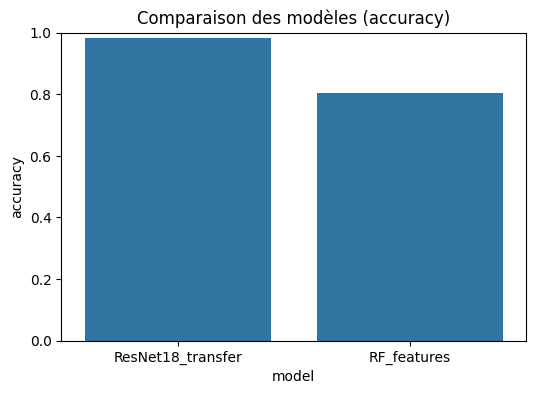

In [9]:
# Évaluation comparative vs baseline classique basée sur les caractéristiques (si CSV disponible)
results = []
results.append({'model':'ResNet18_transfer','accuracy':float(acc_pre)})
features_csv = '../results/combined_run/features/features.csv'
if os.path.exists(features_csv):
    df = pd.read_csv(features_csv).dropna()
    X_cols = [c for c in df.columns if c not in ('image','label')]
    X = df[X_cols].values
    y = df['label'].values
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    from sklearn.model_selection import train_test_split
    from sklearn.ensemble import RandomForestClassifier
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc_rf = accuracy_score(y_test, y_pred)
    results.append({'model':'RF_features','accuracy':float(acc_rf)})
    print('RandomForest (features) accuracy:', acc_rf)
else:
    print('CSV des caractéristiques non trouvé — baseline classique ignorée')

results_df = pd.DataFrame(results).sort_values(by='accuracy', ascending=False)
print(results_df)

plt.figure(figsize=(6,4))
sns.barplot(x='model', y='accuracy', data=results_df)
plt.ylim(0,1)
plt.title('Comparaison des modèles (accuracy)')
os.makedirs('../results/plots/part6_comparison', exist_ok=True)
plt.savefig('../results/plots/part6_comparison/ml_vs_dl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Conclusion 

- Le **ResNet18 pré-entraîné** atteint une accuracy de **98.2%** sur les 10 classes de tomate, contre **80.2%** pour le Random Forest basé sur les caractéristiques extraites.
- Le transfer learning surpasse nettement l'approche classique grâce à sa capacité à apprendre des représentations hiérarchiques complexes directement depuis les pixels.
